# Project 1 - Bonus Question

## Define the data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp

# Given data
t = np.array([0, 2, 6, 10]) # hours
S = np.array([1, 0.68, 0.16, 0.006]) # mmol/L

S0 = S[0] # initial sucrose concentration
C_E0 = 0.01 # initial enzyme concentration

df_raw = pd.DataFrame({"t": t, "C_sucrose": S})
df_raw

,t,C_sucrose
0,0,1.000
1,2,0.680
2,6,0.160
3,10,0.006


## Part A : Plot sucrose concentration vs time

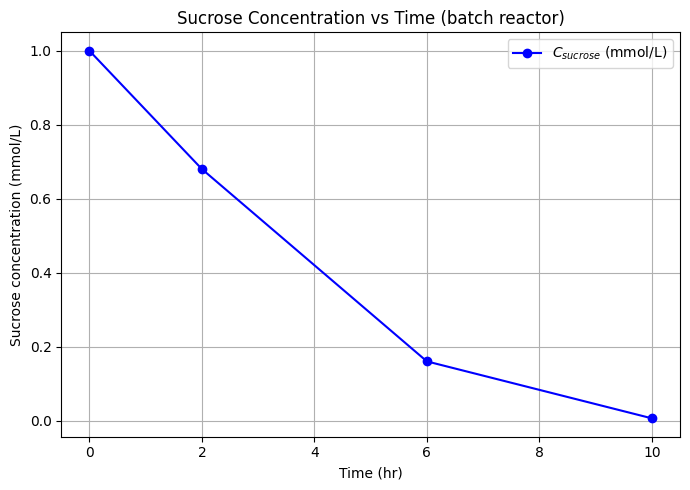

In [2]:
plt.figure(figsize=(7, 5))
plt.plot(t, S, marker="o", color="blue", label="$C_{sucrose}$ (mmol/L)")
plt.xlabel("Time (hr)")
plt.ylabel("Sucrose concentration (mmol/L)")
plt.title("Sucrose Concentration vs Time (batch reactor)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Lineweaver-Burk plot (to find $K_M$ and $v_{max}$)

The Michaelis-Menten equation gives the reaction rate:

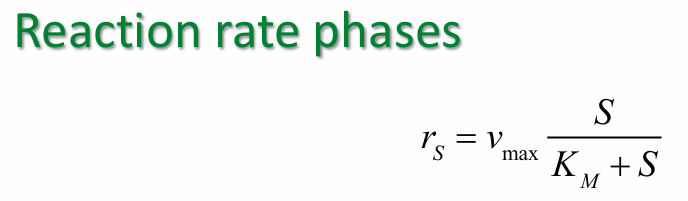

The Lineweaver-Burk linearization is:
$$\frac{1}{r_S} = \frac{K_M}{v_{max}} \cdot \frac{1}{S} + \frac{1}{v_{max}}$$

To use this with our data we estimate the reaction rate in each time interval as:
$$r_S \approx -\frac{\Delta S}{\Delta t}$$

We will use the average substrate concentration $S_{avg} = (S_i + S_{i+1})/2$ in each interval as the representative $S$ :

In [3]:
# Compute S_avg and r_s for each interval
n_intervals = len(t) - 1

r_S = np.zeros(n_intervals)
S_avg = np.zeros(n_intervals)

for i in range(n_intervals):
    r_S[i]   = -(S[i+1] - S[i]) / (t[i+1] - t[i]) # -dS/dt
    S_avg[i] = (S[i] + S[i+1]) / 2 # midpoint S on the interval

one_over_S  = 1.0 / S_avg
one_over_rS = 1.0 / r_S

# intervals list
intervals = [f"{t[i]} - {t[i+1]}" for i in range(n_intervals)]

df_intervals = pd.DataFrame({
    "Interval": intervals,
    "S_avg (mmol/L)": S_avg,
    "r_S (mmol/L/hr)": r_S,
    "1/S (L/mmol)": one_over_S,
    "1/r_S (L*hr/mmol)": one_over_rS
})
df_intervals

,Interval,S_avg (mmol/L),r_S (mmol/L/hr),1/S (L/mmol),1/r_S (L*hr/mmol)
0,0 - 2,0.840,0.1600,1.190476,6.250000
1,2 - 6,0.420,0.1300,2.380952,7.692308
2,6 - 10,0.083,0.0385,12.048193,25.974026


In [4]:
# Lin. reg. : 1/r_S = (Km/vmax)*(1/S) + 1/vmax
slope, intercept = np.polyfit(one_over_S, one_over_rS, 1)

v_max = 1.0 / intercept
K_M = slope * v_max
  
print(f"slope = {slope} -> K_M/v_max")
print(f"intercept = {intercept} -> 1/v_max")
print(f"v_max = {v_max} mmol/(L*hr)")
print(f"K_M = {K_M} mmol/L")

slope = 1.8452883667568436 -> K_M/v_max
intercept = 3.6978760366158885 -> 1/v_max
v_max = 0.2704255064523878 mmol/(L*hr)
K_M = 0.49901304113091893 mmol/L


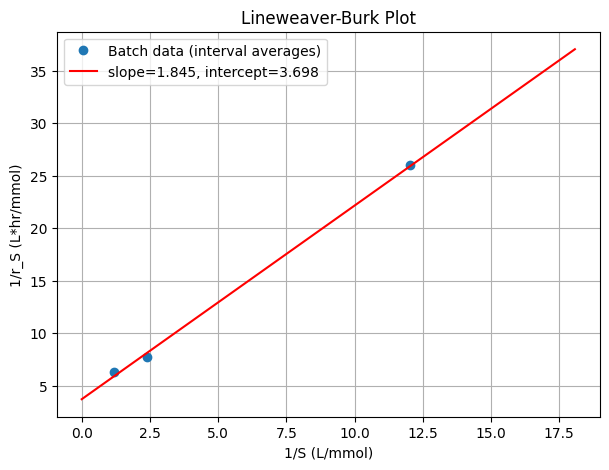

y-intercept = 1/v_max -> v_max = 0.27043 mmol/(L*hr)
slope = K_M/v_max -> K_M = 0.49901 mmol/L


In [5]:
# Lineweaver-Burk plot
one_over_S_line = np.linspace(0, max(one_over_S) * 1.5, 100)
one_over_rS_fit = slope * one_over_S_line + intercept

plt.figure(figsize=(7, 5))
plt.plot(one_over_S, one_over_rS, "o", label="Batch data (interval averages)")
plt.plot(one_over_S_line, one_over_rS_fit, "-", color="red", label=f"slope={slope:.3f}, intercept={intercept:.3f}")

plt.xlabel(r"1/S (L/mmol)")
plt.ylabel(r"1/r_S (L*hr/mmol)")
plt.title("Lineweaver-Burk Plot")

plt.legend()
plt.grid(True)
plt.show()

print(f"y-intercept = 1/v_max -> v_max = {v_max:.5f} mmol/(L*hr)")
print(f"slope = K_M/v_max -> K_M = {K_M:.5f} mmol/L")

## Check results :

We can solve the ODE to check how it fits with our parameters:
$$\frac{dS}{dt} = -\frac{v_{max}\, S}{K_M + S}$$
and compare to the experimental data :

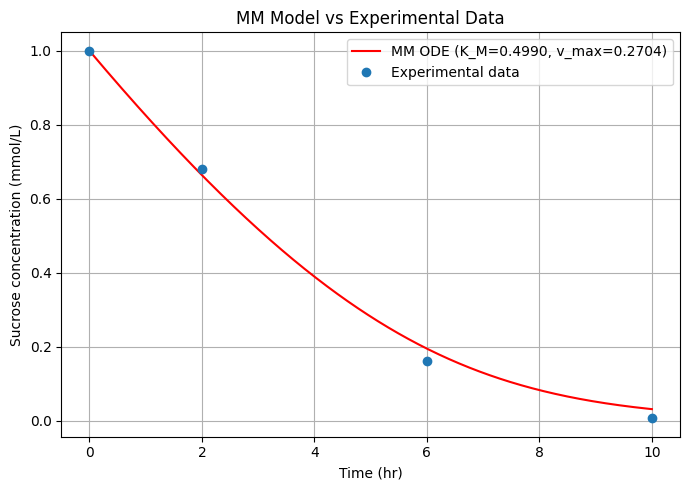

In [6]:
def mm_ode(t, y, v_max, K_M):
    S = y[0]
    dS_dt = -v_max * S / (K_M + S)
    return [dS_dt]

t_eval = np.linspace(0, 10, 500)
sol = solve_ivp(mm_ode, (0, 10), [S0], args=(v_max, K_M), t_eval=t_eval)

plt.figure(figsize=(7, 5))
plt.plot(sol.t, sol.y[0], "-", color="red", label=f"MM ODE (K_M={K_M:.4f}, v_max={v_max:.4f})")
plt.plot(t, S, "o", label="Experimental data")
plt.xlabel("Time (hr)")
plt.ylabel("Sucrose concentration (mmol/L)")
plt.title("MM Model vs Experimental Data")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## No linear approx. : curve_fit on S(t) directly

Instead of linearizing, we can fit $K_M$ and $v_{max}$ directly with "curve_fit"

Lineweaver-Burk: v_max = 0.2704255064523878 mmol/(L*hr) K_M = 0.49901304113091893 mmol/L
curve_fit: v_max = 0.19501314603034933 mmol/(L*hr) K_M = 0.1804670236028604 mmol/L


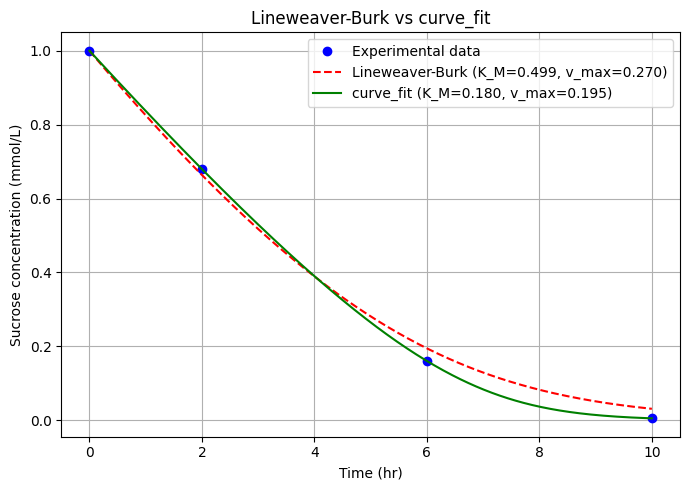

In [7]:
from scipy.optimize import curve_fit

def mm_model(t_data, v_max_fit, K_M_fit):
    sol = solve_ivp(
        mm_ode,
        (t_data[0], t_data[-1]),
        [S0],
        args=(v_max_fit, K_M_fit),
        t_eval=t_data
    )
    return sol.y[0]

popt, pcov = curve_fit(mm_model, t, S, p0=[v_max, K_M])
v_max_cf, K_M_cf = popt

print(f"Lineweaver-Burk: v_max = {v_max} mmol/(L*hr) K_M = {K_M} mmol/L")
print(f"curve_fit: v_max = {v_max_cf} mmol/(L*hr) K_M = {K_M_cf} mmol/L")

# Compare on a plot
t_plot = np.linspace(0, 10, 500)
sol_lb = solve_ivp(mm_ode, (0, 10), [S0], args=(v_max, K_M), t_eval=t_plot).y[0]
sol_cf = solve_ivp(mm_ode, (0, 10), [S0], args=(v_max_cf, K_M_cf), t_eval=t_plot).y[0]

plt.figure(figsize=(7, 5))
plt.plot(t, S, "o", color="blue", label="Experimental data")
plt.plot(t_plot, sol_lb, "--", color="red", label=f"Lineweaver-Burk (K_M={K_M:.3f}, v_max={v_max:.3f})")
plt.plot(t_plot, sol_cf, "-", color="green", label=f"curve_fit (K_M={K_M_cf:.3f}, v_max={v_max_cf:.3f})")
plt.xlabel("Time (hr)")
plt.ylabel("Sucrose concentration (mmol/L)")
plt.title("Lineweaver-Burk vs curve_fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()